In [21]:
import numpy as np
import matplotlib.pyplot as plt


In [22]:
DT = 0.1  # time step (s)

MGUK_MAX_POWER = 120_000        # W
MGUK_MAX_ENERGY_LAP = 4e6       # J

BATTERY_CAPACITY = 4e6          # J
SOC_MIN, SOC_MAX = 0.2, 1.0

VEHICLE_MASS = 800              # kg (car + driver)
REGEN_EFFICIENCY = 0.6
BASE_LAP_TIME = 92.0            # realistic Canada baseline


In [23]:
track_canada = [
    {"name": "Start/Finish Straight", "type": "accel", "length": 950, "v_entry": 90,  "v_exit": 320},
    {"name": "Turn 1–2 Chicane",      "type": "brake", "length": 180, "v_entry": 320, "v_exit": 120},
    {"name": "Straight to T3",        "type": "accel", "length": 600, "v_entry": 120, "v_exit": 280},
    {"name": "Turn 3–4",              "type": "brake", "length": 160, "v_entry": 280, "v_exit": 110},
    {"name": "Casino Straight",       "type": "accel", "length": 800, "v_entry": 110, "v_exit": 300},
    {"name": "Hairpin",               "type": "brake", "length": 170, "v_entry": 300, "v_exit": 95},
    {"name": "Back Straight",          "type": "accel", "length": 900, "v_entry": 95,  "v_exit": 330},
    {"name": "Wall of Champions",      "type": "brake", "length": 150, "v_entry": 330, "v_exit": 140},
]


In [24]:
track = track_canada


In [25]:
def energy_policy(segment, soc, energy_used):
    if segment["type"] == "accel" and soc > 0.35 and energy_used < MGUK_MAX_ENERGY_LAP:
        return MGUK_MAX_POWER * (soc - SOC_MIN)
    return 0.0


In [26]:
def simulate_lap(track):
    soc = 0.8
    energy_used = 0.0
    time = 0.0

    soc_trace, power_trace = [], []

    for seg in track:
        v_entry = seg["v_entry"]/3.6
        v_exit  = seg["v_exit"]/3.6
        v_avg   = 0.5*(v_entry + v_exit)

        duration = seg["length"] / max(v_avg, 1e-3)
        steps = max(1, int(duration / DT))

        # total harvestable energy for this braking segment (J)
        if seg["type"] == "brake":
            delta_E = 0.5 * VEHICLE_MASS * (v_entry**2 - v_exit**2)
            harvest_total = max(0.0, delta_E) * REGEN_EFFICIENCY
            harvest_per_step = harvest_total / steps
        else:
            harvest_per_step = 0.0

        for _ in range(steps):
            # harvest (during braking) gradually
            if harvest_per_step > 0:
                soc += harvest_per_step / BATTERY_CAPACITY

            # deploy (during accel) based on your policy
            power = energy_policy(seg, soc, energy_used)

            if power > 0:
                energy = power * DT
                if energy_used + energy <= MGUK_MAX_ENERGY_LAP:
                    energy_used += energy
                    soc -= energy / BATTERY_CAPACITY
                else:
                    power = 0.0

            soc = np.clip(soc, SOC_MIN, SOC_MAX)

            soc_trace.append(soc)
            power_trace.append(power)
            time += DT

    # realistic lap-time mapping
    GAIN_PER_MJ = 0.5
    lap_time = BASE_LAP_TIME - GAIN_PER_MJ * (energy_used / 1e6)
    return lap_time, soc_trace, power_trace, energy_used


Lap time: 90.00 s
Energy deployed: 4.00 MJ / 4.00 MJ


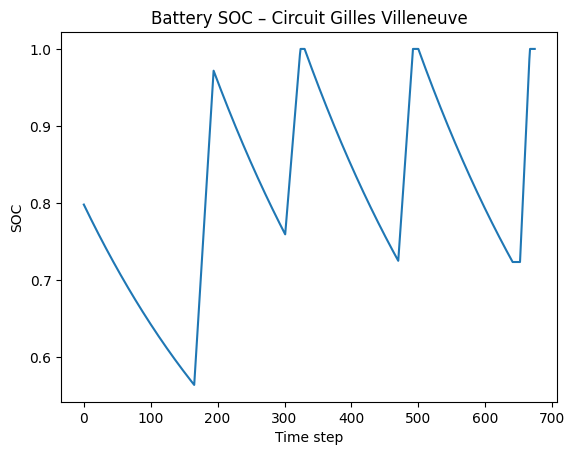

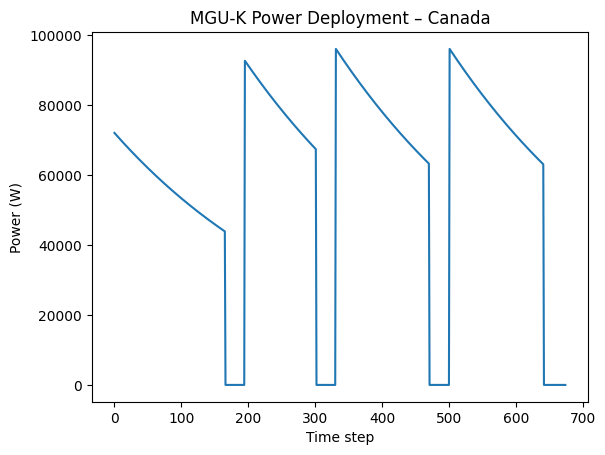

In [27]:
lap_time, soc, power, energy_used = simulate_lap(track)
print(f"Lap time: {lap_time:.2f} s")
print(f"Energy deployed: {energy_used/1e6:.2f} MJ / 4.00 MJ")


plt.figure()
plt.plot(soc)
plt.title("Battery SOC – Circuit Gilles Villeneuve")
plt.ylabel("SOC")
plt.xlabel("Time step")
plt.show()

plt.figure()
plt.plot(power)
plt.title("MGU-K Power Deployment – Canada")
plt.ylabel("Power (W)")
plt.xlabel("Time step")
plt.show()
